# 02 — Model Evaluation

Systematic post-training analysis of the YOLO-OBB boat detection model.

All metric computation is delegated to `src.vessels_detect.evaluation.metrics` and
`src.vessels_detect.evaluation.postprocess_eval`.  
This notebook contains only configuration constants and visualisation code.

| § | Description |
|---|-------------|
| 1 | Setup & constants |
| 2 | Model loading |
| 3 | Formal `model.val()` metrics |
| 4 | Manual evaluation **with Global NMS postprocessing** |
| 5 | Normalised confusion matrix |

In [1]:
%env OPENCV_LOG_LEVEL=ERROR
import sys, logging
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import cv2
import rasterio
from collections import defaultdict
from tqdm import tqdm

# ── Project — evaluation ──────────────────────────────────────────────────
from src.vessels_detect.utils.config import load_config
from src.vessels_detect.evaluation.metrics import (
    compute_per_class_metrics,
    compute_confusion_matrix,
    build_size_dataframe,
    build_distribution_dataframe,
    parse_label_file,
    match_detections,
    compute_crop_metrics,
    build_crop_summary,
    calculate_counting_bias,
    build_bias_dataframe,
)
# ── Project — postprocessing-aware evaluation (new) ───────────────────────
from src.vessels_detect.evaluation.postprocess_eval import (
    load_split_gt_crs,
    match_global_detections_crs,
    build_performance_dataframe,
)
# ── Project — inference pipeline ─────────────────────────────────────────
from src.vessels_detect.utils.notebook_helpers import build_predictor_config
from src.vessels_detect.inference.predictor import YoloPredictor
from src.vessels_detect.inference.postprocess import GlobalNMS
from src.vessels_detect.inference.filter import CoastlineFilter

logging.getLogger("ultralytics").setLevel(logging.ERROR)
logging.getLogger("src.vessels_detect.inference.predictor").setLevel(logging.WARNING)

plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.35,
    "legend.framealpha": 0.7,
    "legend.fontsize": 9,
})
print("Imports OK.")

env: OPENCV_LOG_LEVEL=ERROR
Imports OK.


## 1. Constants

In [2]:
MODEL_PATH    = Path("../boat_obb_v2m2/weights/best.pt")
DATA_PATH     = Path("../data/dataset.yaml")
PROCESSED_DIR = Path("../data/processed")
LABELS_ROOT   = PROCESSED_DIR / "labels"
IMAGES_DIR    = PROCESSED_DIR / "images"
LABELS_DIR    = PROCESSED_DIR / "labels"

# Splits used by §3 (model.val) and §5 (confusion matrix)
VAL_SPLIT         = "test"
# Splits evaluated in §4 (manual evaluation with Global NMS)
EVAL_SPLITS       = ["test"]

FINAL_CONF        = 0.20
FINAL_IOU         = 0.30    # YOLO-internal NMS IoU
GLOBAL_NMS_IOU    = 0.30    # cross-tile suppression IoU  ← new
IMG_SIZE          = 640
TILE_SIZE         = 640

# Optional coastline filter — set to a valid path to enable
COASTLINE_MASK_PATH = None  # e.g. Path("../data/masks/valid_maritime_area.geojson")

print(f"Model        : {MODEL_PATH}")
print(f"Data         : {DATA_PATH}")
print(f"Conf         : {FINAL_CONF}  |  YOLO IoU : {FINAL_IOU}  |  Global NMS IoU : {GLOBAL_NMS_IOU}")
print(f"Eval splits  : {EVAL_SPLITS}")

Model        : ../boat_obb_v2m2/weights/best.pt
Data         : ../data/dataset.yaml
Conf         : 0.2  |  YOLO IoU : 0.3  |  Global NMS IoU : 0.3
Eval splits  : ['test']


## 2. Model Loading

In [3]:
from ultralytics import YOLO

model       = YOLO(MODEL_PATH)
CLASS_NAMES = model.names
print("Classes:", CLASS_NAMES)

Classes: {0: 'Pirogue', 1: 'Double_hulled_Pirogue', 2: 'Small_Motorboat', 3: 'Medium_Motorboat', 4: 'Large_Motorboat', 5: 'Sailing_Boat'}


## 3. Formal Evaluation — `model.val()`

Standard Ultralytics evaluation on the `test` split — no Global NMS applied here  
(tile-level YOLO NMS only).  Use §4 for the postprocessing-corrected numbers.

In [4]:
metrics = model.val(
    data=str(DATA_PATH),
    split=VAL_SPLIT,
    imgsz=IMG_SIZE,
    conf=FINAL_CONF,
    iou=FINAL_IOU,
    save_json=False,
    plots=False,
    verbose=False,
)

print(f"mAP50    : {metrics.box.map50:.4f}")
print(f"mAP50-95 : {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall   : {metrics.box.mr:.4f}")

df_val = compute_per_class_metrics(metrics, CLASS_NAMES, LABELS_ROOT, test_split=VAL_SPLIT)
display(df_val)

Ultralytics 8.4.1 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4080, 15946MiB)
YOLO26m-obb summary (fused): 142 layers, 21,202,529 parameters, 0 gradients, 71.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 6328.7±1200.3 MB/s, size: 601.5 KB)
val: Scanning /home/thomas/Documents/test/pleiades-boat-detection/data/processed/labels/test.cache... 12915 images, 12742 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 12915/12915 3.4Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 808/808 12.3it/s 1:06<0.1ss
                   all      12915        481      0.324      0.301      0.264      0.193
Speed: 0.3ms preprocess, 4.6ms inference, 0.0ms loss, 0.0ms postprocess per image
mAP50    : 0.2643
mAP50-95 : 0.1935
Precision: 0.3237
Recall   : 0.3011


,Class,Support,Precision,Recall,F1-score,mAP50,mAP50-95
0,Medium_Motorboat,41,0.6291,0.3659,0.4627,0.4819,0.3268
1,Small_Motorboat,61,0.3396,0.7213,0.4618,0.3585,0.2887
2,Double_hulled_Pirogue,142,0.5000,0.1479,0.2283,0.3384,0.2670
3,Sailing_Boat,15,0.0000,0.0000,0.0000,0.0000,0.1935
4,Pirogue,222,0.1497,0.2703,0.1926,0.1426,0.0848
5,Large_Motorboat,0,NaN,NaN,NaN,NaN,NaN
6,**Global**,481,0.3237,0.3011,0.3120,0.2643,0.1935


## 4. Manual Evaluation with Global NMS Postprocessing

Mirrors the production inference pipeline exactly:

```
YoloPredictor  →  GlobalNMS  →  [CoastlineFilter]  →  CRS-space matching vs GT
```

Detections and GT are both projected to the tile's native CRS (e.g. UTM) before  
matching, so cross-tile duplicates that were already suppressed by Global NMS  
are correctly excluded from the TP/FP/FN counts.

| Sub-step | What happens |
|----------|--------------|
| **4a** | Raw tile predictions — `YoloPredictor` |
| **4b** | Cross-tile deduplication — `GlobalNMS` |
| **4c** | *(optional)* Coastline filter |
| **4d** | GT loading in CRS space |
| **4e** | Global CRS-space matching & DataFrame |

In [5]:
# ── 4a · Raw tile predictions ─────────────────────────────────────────────
run_config = build_predictor_config(
    weights = MODEL_PATH,
    conf    = FINAL_CONF,
    iou     = FINAL_IOU,
    imgsz   = IMG_SIZE,
)
predictor = YoloPredictor(config=run_config)

tile_predictions = []
for split in EVAL_SPLITS:
    split_dir  = IMAGES_DIR / split
    tile_paths = sorted(p for p in split_dir.iterdir() if p.suffix.lower() in {".tif", ".tiff"})

    with tqdm(total=len(tile_paths), desc=f"Predicting [{split}]", unit="tile") as pbar:
        for record in predictor.predict_directory(tiles_dir=split_dir):
            tile_predictions.append(record)
            pbar.update(1)
            pbar.set_postfix(raw_dets=sum(tp.n_detections for tp in tile_predictions))

total_raw = sum(tp.n_detections for tp in tile_predictions)
print(f"\n  Tiles processed   : {len(tile_predictions)}")
print(f"  Raw detections    : {total_raw}")

Predicting [test]: 100%|██████████| 12915/12915 [02:36<00:00, 82.36tile/s, raw_dets=641]


  Tiles processed   : 12915
  Raw detections    : 641


In [6]:
# ── 4b · Global NMS ───────────────────────────────────────────────────────
global_nms = GlobalNMS(iou_threshold=GLOBAL_NMS_IOU)
detections = global_nms.run(predictions=tile_predictions)

print(f"  After Global NMS  : {len(detections)}  ({total_raw - len(detections)} suppressed)")

  After Global NMS  : 454  (187 suppressed)


In [7]:
# ── 4c · Coastline filter (optional) ─────────────────────────────────────
if COASTLINE_MASK_PATH is not None:
    coast_filter = CoastlineFilter(valid_area_path=COASTLINE_MASK_PATH)
    n_before   = len(detections)
    detections = coast_filter.run(detections=detections)
    print(f"  After coast. filter : {len(detections)}  ({n_before - len(detections)} removed)")
else:
    print("  Coastline filter : skipped  (set COASTLINE_MASK_PATH to enable)")

  Coastline filter : skipped  (set COASTLINE_MASK_PATH to enable)


In [8]:
# ── 4d · Load GT in CRS space ─────────────────────────────────────────────
# load_split_gt_crs:
#   1. Opens each GeoTIFF to read its Affine transform and CRS string.
#   2. Calls parse_label_file(lbl_path, w, h) to get pixel-space corners.
#   3. Projects corners to CRS via project_corners_to_crs(pixel_corners, transform).
#   4. Normalises the CRS to an EPSG authority code (e.g. "EPSG:32632").
# Each element of gt_crs_list is: (class_id, crs_corners (4,2), crs_string).
# The CRS string is CRITICAL — match_global_detections_crs skips GT/detection
# pairs that are in different UTM zones, preventing IoU=0 from cross-zone
# coordinate mismatches.
gt_crs_list = load_split_gt_crs(
    images_dir = IMAGES_DIR,
    labels_dir = LABELS_DIR,
    splits     = EVAL_SPLITS,
)

print(f"  GT annotations loaded : {len(gt_crs_list)}")

# ── Sanity check: verify GT and detection CRS zones overlap ───────────────
gt_crs_zones  = set(crs for _, _, crs in gt_crs_list)
det_crs_zones = set(
    (lambda s: f"EPSG:{__import__('pyproj').CRS(s).to_epsg()}" if __import__('pyproj').CRS(s).to_epsg() else s)(d.crs)
    for d in detections
)
common = gt_crs_zones & det_crs_zones
print(f"  GT CRS zones          : {gt_crs_zones}")
print(f"  Detection CRS zones   : {det_crs_zones}")
if not common:
    print("  ⚠️  WARNING: no overlapping CRS zones — all IoUs will be 0. Check tile CRS.")
else:
    print(f"  ✓ Shared CRS zones    : {common}")

  GT annotations loaded : 481
  GT CRS zones          : {'EPSG:32739'}
  Detection CRS zones   : {'EPSG:32739'}
  ✓ Shared CRS zones    : {'EPSG:32739'}


In [9]:
# ── 4e · Global CRS-space matching & performance DataFrame ────────────────
# match_global_detections_crs:
#   - Processes detections in descending confidence order.
#   - For each detection, only considers GT annotations that share both
#     the same class_id AND the same normalised CRS zone.
#   - Computes rotated-polygon IoU via cv2.intersectConvexConvex.
#   - Assigns the highest-IoU GT (>= iou_threshold) as TP; marks it consumed.
m_pred, m_gt = match_global_detections_crs(
    gt_list       = gt_crs_list,
    detections    = detections,
    iou_threshold = GLOBAL_NMS_IOU,
)

# Accumulate TP / FP / FN
stats = {cid: {"TP": 0, "FP": 0, "FN": 0} for cid in CLASS_NAMES.keys()}

for pi, det in enumerate(detections):
    if m_pred[pi]:
        stats[det.class_id]["TP"] += 1
    else:
        stats[det.class_id]["FP"] += 1

for gi, (gt_cid, _, __) in enumerate(gt_crs_list):
    if not m_gt[gi]:
        stats[gt_cid]["FN"] += 1

df_perf = build_performance_dataframe(stats=stats, class_names=CLASS_NAMES)
display(df_perf)

,Class,TP,FP,FN,Precision,Recall,F1-Score,Bias (%)
0,Pirogue,43,257,179,0.1433,0.1937,0.1648,35.14
1,Double_hulled_Pirogue,12,12,130,0.5000,0.0845,0.1446,-83.10
2,Small_Motorboat,31,69,30,0.3100,0.5082,0.3851,63.93
3,Medium_Motorboat,10,6,31,0.6250,0.2439,0.3509,-60.98
4,Large_Motorboat,0,9,0,0.0000,0.0000,0.0000,0.00
5,Sailing_Boat,1,4,14,0.2000,0.0667,0.1000,-66.67
6,ALL_CLASSES_MICRO,97,357,384,0.2137,0.2017,0.2075,-5.61


## 5. Normalised Confusion Matrix

Built from `model.val()` — tile-level YOLO NMS only (no Global NMS).  
Useful for diagnosing class confusion independently of tile-border duplicates.

Ultralytics 8.4.1 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4080, 15946MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4323.6±555.2 MB/s, size: 741.8 KB)
val: Scanning /home/thomas/Documents/test/pleiades-boat-detection/data/processed/labels/test.cache... 12915 images, 12742 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 12915/12915 6.0Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 808/808 12.2it/s 1:06<0.1ss
                   all      12915        481      0.324      0.301      0.264      0.193
Speed: 0.3ms preprocess, 4.6ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /home/thomas/Documents/test/pleiades-boat-detection/notebooks/runs/obb/val3


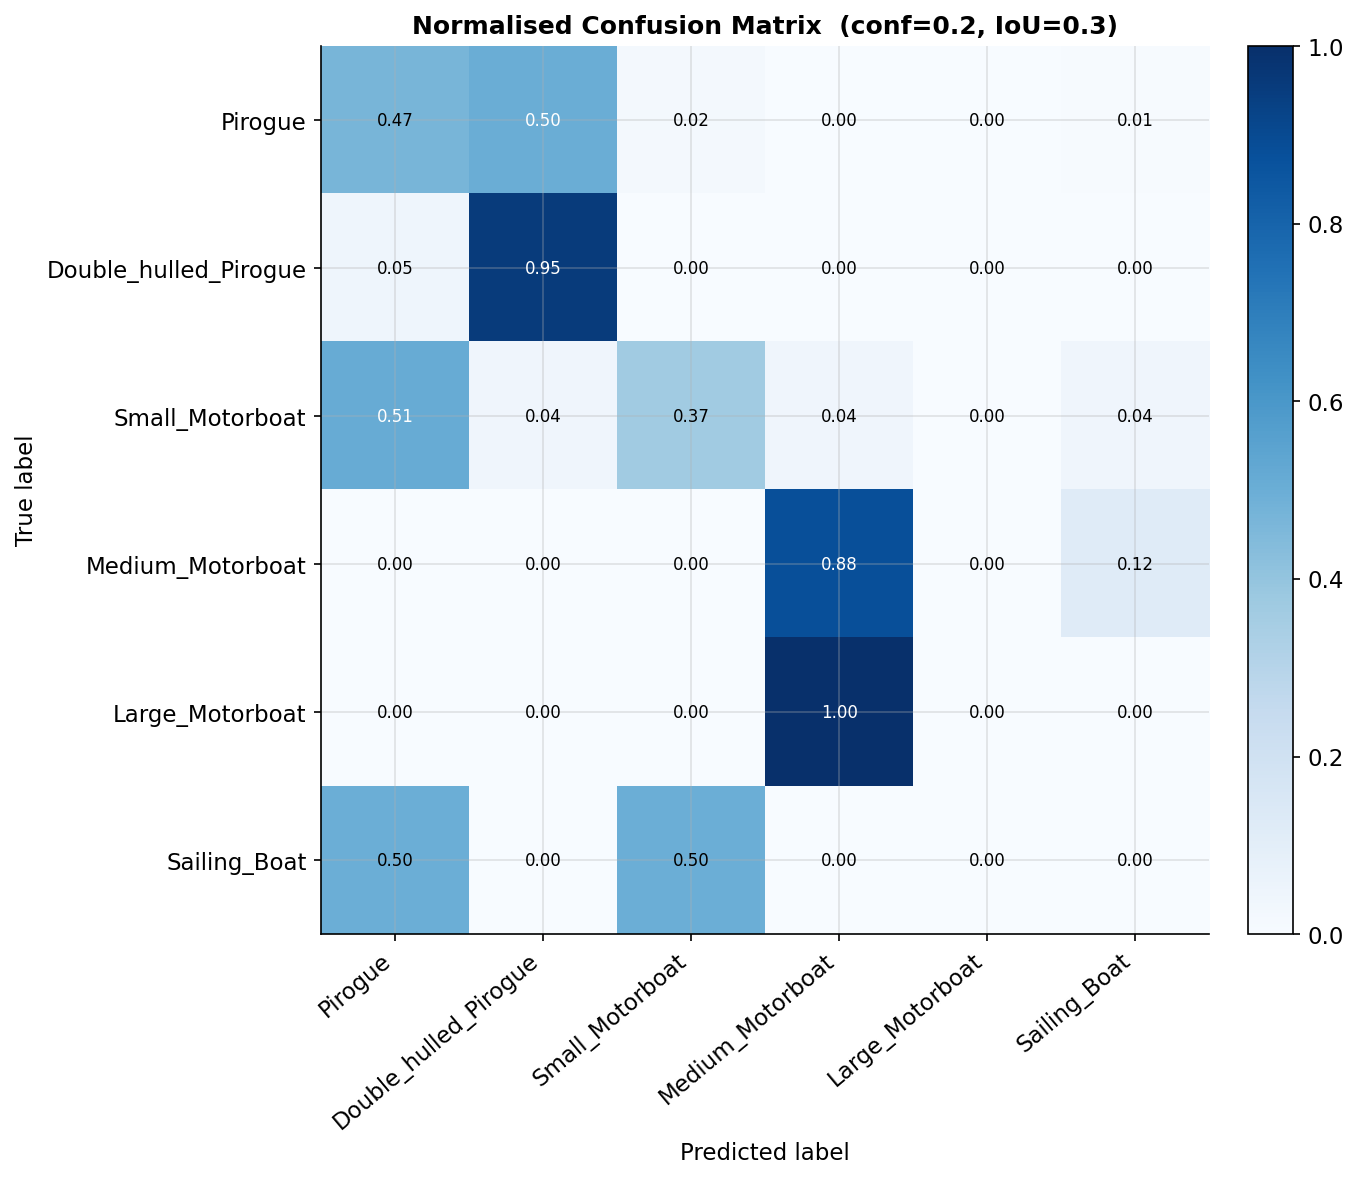

In [10]:
%matplotlib inline
from IPython.display import display as ipy_display

metrics_cm = model.val(
    data=str(DATA_PATH),
    split=VAL_SPLIT,
    imgsz=IMG_SIZE,
    conf=FINAL_CONF,
    iou=FINAL_IOU,
    plots=True,
    save_json=False,
    verbose=False,
)

# model.val(plots=True) creates and closes its own figures, which can leave
# the matplotlib state in a mode where subsequent figures render as text.
# plt.close('all') resets the figure manager before we build our own plot.
plt.close("all")

cm_norm, labels = compute_confusion_matrix(metrics_cm, CLASS_NAMES)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm_norm, vmin=0, vmax=1, cmap="Blues")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ticks = np.arange(len(labels))
ax.set_xticks(ticks); ax.set_xticklabels(labels, rotation=40, ha="right")
ax.set_yticks(ticks); ax.set_yticklabels(labels)

thresh = cm_norm.max() / 2.0
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        v = cm_norm[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    fontsize=8, color="white" if v > thresh else "black")

ax.set_ylabel("True label")
ax.set_xlabel("Predicted label")
ax.set_title(
    f"Normalised Confusion Matrix  (conf={FINAL_CONF}, IoU={FINAL_IOU})",
    fontweight="bold",
)
plt.tight_layout()
ipy_display(fig)
plt.close(fig)